# Notebook 02 — Arquitectura Línea de Base (CNN Binaria)
## Clasificación de Lesiones Cutáneas Pigmentadas (HAM10000)
**Iteración 1:** CNN desde cero · Clasificación binaria (Maligno vs. Benigno)

---
### Objetivo de este notebook
Establecer una **línea de base** con una CNN propia entrenada desde cero en PyTorch.  
Se compara el rendimiento **con y sin pesos de clase** para cuantificar el efecto  
de la estrategia de mitigación de desbalance — análisis solicitado explícitamente.

### Estructura
1. Ingesta y DataLoaders binarios (reutiliza split del NB01)
2. Arquitectura CNN baseline (3 bloques conv + FC)
3. Entrenamiento sin pesos de clase (baseline puro)
4. Entrenamiento con pesos de clase (baseline mejorado)
5. Comparativa de curvas de aprendizaje
6. Evaluación completa en **test set**: balanced accuracy, F1-macro, AUC-ROC, matriz de confusión


In [4]:
# ============================================================
# CELDA 1: INSTALACIONES Y CONFIGURACIÓN
# ============================================================
!pip install -q kaggle scikit-learn matplotlib seaborn pandas Pillow torch torchvision tqdm
import os, json, zipfile, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                              balanced_accuracy_score, roc_auc_score,
                              f1_score, roc_curve, auc)
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Dispositivo: cpu


In [7]:
# ============================================================
# CELDA 2: INGESTA DE DATOS — KAGGLE SECRETS O GOOGLE DRIVE
# ============================================================
import os, json, zipfile
import glob as glob_module

UNZIP_DIR       = '/content/dataset/unzipped'
DRIVE_FOLDER_ID = '1CCdAHVv0K3whsHxedqVqgqzs2aesWIYR'

if not os.path.exists(UNZIP_DIR) or len(os.listdir(UNZIP_DIR)) == 0:
    os.makedirs(UNZIP_DIR, exist_ok=True)

    # ── Intento 1: Kaggle Secrets ──────────────────────────────
    kaggle_ok = False
    try:
        from google.colab import userdata
        KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
        KAGGLE_KEY      = userdata.get('KAGGLE_KEY')
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/kaggle.json', 'w') as f:
            json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/dataset -q
        with zipfile.ZipFile('/content/dataset/skin-cancer-mnist-ham10000.zip', 'r') as zf:
            zf.extractall(UNZIP_DIR)
        kaggle_ok = True
        print("✅ Dataset cargado desde Kaggle")
    except Exception:
        print("⚠️  Kaggle Secrets no disponibles → usando Google Drive...")

    # ── Intento 2: Google Drive (fallback) ────────────────────
    if not kaggle_ok:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_PATH = '/content/drive/MyDrive/HAM10000_dataset'
        if os.path.exists(DRIVE_PATH):
            print("Copiando desde Google Drive (puede tardar unos minutos)...")
            !cp -r "{DRIVE_PATH}"/* "{UNZIP_DIR}/"
            print("✅ Dataset cargado desde Google Drive")
        else:
            !pip install -q gdown
            import gdown
            gdown.download_folder(
                f'https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID}',
                output=UNZIP_DIR, quiet=False, use_cookies=False)
            print("✅ Dataset descargado desde Google Drive (enlace público)")
else:
    print("✅ Dataset ya disponible en", UNZIP_DIR)

# ── Buscar CSV automáticamente ────────────────────────────────
csvs    = glob_module.glob('/content/**/*metadata*.csv', recursive=True)
CSV_PATH  = csvs[0] if csvs else f'{UNZIP_DIR}/HAM10000_metadata.csv'
IMAGE_DIR = UNZIP_DIR
print(f"CSV encontrado: {CSV_PATH}")

✅ Dataset ya disponible en /content/dataset/unzipped
CSV encontrado: /content/dataset/unzipped/HAM10000_metadata.csv


In [8]:
# ============================================================
# CELDA 3: DATASET BINARIO Y SPLIT POR LESION_ID
# ============================================================
CLASES   = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
MALIGNOS = ['mel', 'bcc', 'akiec']

class HAM10000_Binario(Dataset):
    """Dataset binario — imágenes RGB (3 canales, 600x450 px originales → 224x224 px)."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df['path'].iloc[idx]).convert('RGB')
        label = 1 if self.df['dx'].iloc[idx] in MALIGNOS else 0
        if self.transform:
            image = self.transform(image)
        return image, label

# Metadatos y rutas
df_meta = pd.read_csv(CSV_PATH)
todas   = glob(os.path.join(UNZIP_DIR, '**', '*.jpg'), recursive=True)
df_meta['path'] = df_meta['image_id'].map(
    {os.path.splitext(os.path.basename(x))[0]: x for x in todas})
df_meta = df_meta.dropna(subset=['path'])

# Split por lesion_id (sin data leakage de paciente)
groups = df_meta['lesion_id'].values
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
idx_tv, idx_test = next(gss_test.split(np.arange(len(df_meta)), groups=groups))
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
idx_tr_r, idx_val_r = next(gss_val.split(idx_tv, groups=groups[idx_tv]))
idx_train, idx_val = idx_tv[idx_tr_r], idx_tv[idx_val_r]

df_train = df_meta.iloc[idx_train]
df_val   = df_meta.iloc[idx_val]
df_test  = df_meta.iloc[idx_test]
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_loader = DataLoader(HAM10000_Binario(df_train, transform_train),
                          batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(HAM10000_Binario(df_val,   transform_val),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(HAM10000_Binario(df_test,  transform_val),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Pesos de clase (para la variante con pesos)
etiquetas_bin_train = df_train['dx'].apply(lambda x: 1 if x in MALIGNOS else 0).values
pesos_bin = compute_class_weight('balanced', classes=np.array([0,1]), y=etiquetas_bin_train)
pesos_bin_tensor = torch.tensor(pesos_bin, dtype=torch.float).to(device)
print(f"Pesos binarios → Benigno: {pesos_bin[0]:.3f} | Maligno: {pesos_bin[1]:.3f}")


Train: 7984 | Val: 1005 | Test: 1026
Pesos binarios → Benigno: 0.619 | Maligno: 2.592


### Celda 4 — Arquitectura CNN Baseline
3 bloques convolucionales (Conv2d → BatchNorm → ReLU → MaxPool) + 2 capas FC con Dropout.  
Entrada: tensor RGB 224×224 → Salida: 2 logits (Benigno, Maligno).


In [9]:
# ============================================================
# CELDA 4: ARQUITECTURA CNN BASELINE
# ============================================================
class BaselineCNN(nn.Module):
    """
    CNN desde cero — 3 bloques conv + clasificador FC.
    Entrada: imagen RGB 224x224 (3 canales).
    Salida : 2 logits (Benigno=0, Maligno=1).
    """
    def __init__(self):
        super().__init__()
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.bloque2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.bloque3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        # 224 → 112 → 56 → 28  (3 MaxPool2d de stride 2)
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        return self.clasificador(x)

# Conteo de parámetros
modelo_test = BaselineCNN()
total_params = sum(p.numel() for p in modelo_test.parameters())
trainable    = sum(p.numel() for p in modelo_test.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable:,}")
del modelo_test


Parámetros totales    : 12,869,634
Parámetros entrenables: 12,869,634


In [10]:
# ============================================================
# CELDA 5: FUNCIÓN DE ENTRENAMIENTO GENÉRICA
# ============================================================
def entrenar(modelo, train_loader, val_loader, criterio, epochs=10, lr=0.001,
             nombre='modelo'):
    optimizador = optim.Adam(modelo.parameters(), lr=lr)
    historial   = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}

    for epoch in range(epochs):
        # ── TRAIN ──
        modelo.train()
        t_loss, t_corr, t_tot = 0., 0, 0
        for X, y in tqdm(train_loader, desc=f'[{nombre}] Época {epoch+1}/{epochs}', leave=False):
            X, y = X.to(device), y.to(device)
            optimizador.zero_grad()
            out  = modelo(X)
            loss = criterio(out, y)
            loss.backward()
            optimizador.step()
            t_loss += loss.item() * X.size(0)
            t_corr += (out.argmax(1) == y).sum().item()
            t_tot  += y.size(0)

        # ── VALIDACIÓN ──
        modelo.eval()
        v_loss, v_corr, v_tot = 0., 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out  = modelo(X)
                loss = criterio(out, y)
                v_loss += loss.item() * X.size(0)
                v_corr += (out.argmax(1) == y).sum().item()
                v_tot  += y.size(0)

        historial['train_loss'].append(t_loss / t_tot)
        historial['val_loss'].append(v_loss / v_tot)
        historial['train_acc'].append(t_corr / t_tot)
        historial['val_acc'].append(v_corr / v_tot)

        print(f"Época {epoch+1:2d} | "
              f"Train Loss: {historial['train_loss'][-1]:.4f} Acc: {historial['train_acc'][-1]:.4f} | "
              f"Val Loss: {historial['val_loss'][-1]:.4f} Acc: {historial['val_acc'][-1]:.4f}")

    return historial


### Celda 6 — Entrenamiento SIN pesos de clase
Baseline puro: `CrossEntropyLoss` estándar (sin corrección de desbalance).


In [ ]:
# ============================================================
# CELDA 6: ENTRENAMIENTO — SIN PESOS DE CLASE
# ============================================================
EPOCHS = 10

modelo_sin_pesos = BaselineCNN().to(device)
criterio_sin     = nn.CrossEntropyLoss()  # sin pesos

print("▶ Entrenando CNN baseline SIN pesos de clase...")
hist_sin = entrenar(modelo_sin_pesos, train_loader, val_loader,
                    criterio_sin, epochs=EPOCHS, nombre='Sin Pesos')
print("✅ Entrenamiento sin pesos finalizado")


▶ Entrenando CNN baseline SIN pesos de clase...


Época  1 | Train Loss: 0.7468 Acc: 0.7932 | Val Loss: 0.4356 Acc: 0.7910


Época  2 | Train Loss: 0.4240 Acc: 0.8067 | Val Loss: 0.4162 Acc: 0.7910


Época  3 | Train Loss: 0.4225 Acc: 0.8066 | Val Loss: 0.4157 Acc: 0.7910


Época  4 | Train Loss: 0.4095 Acc: 0.8070 | Val Loss: 0.4048 Acc: 0.7910


...

Época  6 | Train Loss: 0.4100 Acc: 0.8071 | Val Loss: 0.4070 Acc: 0.7910


Época  7 | Train Loss: 0.4149 Acc: 0.8069 | Val Loss: 0.3952 Acc: 0.7910


Época  8 | Train Loss: 0.4019 Acc: 0.8071 | Val Loss: 0.3955 Acc: 0.7910


Época  9 | Train Loss: 0.3992 Acc: 0.8071 | Val Loss: 0.4080 Acc: 0.7910


Época 10 | Train Loss: 0.4102 Acc: 0.8071 | Val Loss: 0.3838 Acc: 0.7910
✅ Entrenamiento sin pesos finalizado


### Celda 7 — Entrenamiento CON pesos de clase
Estrategia de mitigación de desbalance: `CrossEntropyLoss(weight=pesos_bin_tensor)`.  
La clase maligna (minoritaria, ~19.5%) recibe un peso mayor → la red penaliza más sus errores.


In [ ]:
# ============================================================
# CELDA 7: ENTRENAMIENTO — CON PESOS DE CLASE
# ============================================================
modelo_con_pesos = BaselineCNN().to(device)
criterio_con     = nn.CrossEntropyLoss(weight=pesos_bin_tensor)

print("▶ Entrenando CNN baseline CON pesos de clase...")
hist_con = entrenar(modelo_con_pesos, train_loader, val_loader,
                    criterio_con, epochs=EPOCHS, nombre='Con Pesos')
print("✅ Entrenamiento con pesos finalizado")


▶ Entrenando CNN baseline CON pesos de clase...


Época  1 | Train Loss: 1.6745 Acc: 0.5726 | Val Loss: 0.4912 Acc: 0.6408


Época  2 | Train Loss: 0.5650 Acc: 0.6085 | Val Loss: 0.4562 Acc: 0.7532


Época  3 | Train Loss: 0.5397 Acc: 0.6201 | Val Loss: 0.4284 Acc: 0.7423


Época  4 | Train Loss: 0.5455 Acc: 0.6835 | Val Loss: 0.4979 Acc: 0.6338


...

Época  6 | Train Loss: 0.5412 Acc: 0.7177 | Val Loss: 0.4495 Acc: 0.6955


Época  7 | Train Loss: 0.5341 Acc: 0.7196 | Val Loss: 0.6463 Acc: 0.5930


Época  8 | Train Loss: 0.5267 Acc: 0.7460 | Val Loss: 0.4760 Acc: 0.6527


Época  9 | Train Loss: 0.5533 Acc: 0.7370 | Val Loss: 0.5775 Acc: 0.7463


Época 10 | Train Loss: 0.5356 Acc: 0.7323 | Val Loss: 0.4930 Acc: 0.7303
✅ Entrenamiento con pesos finalizado


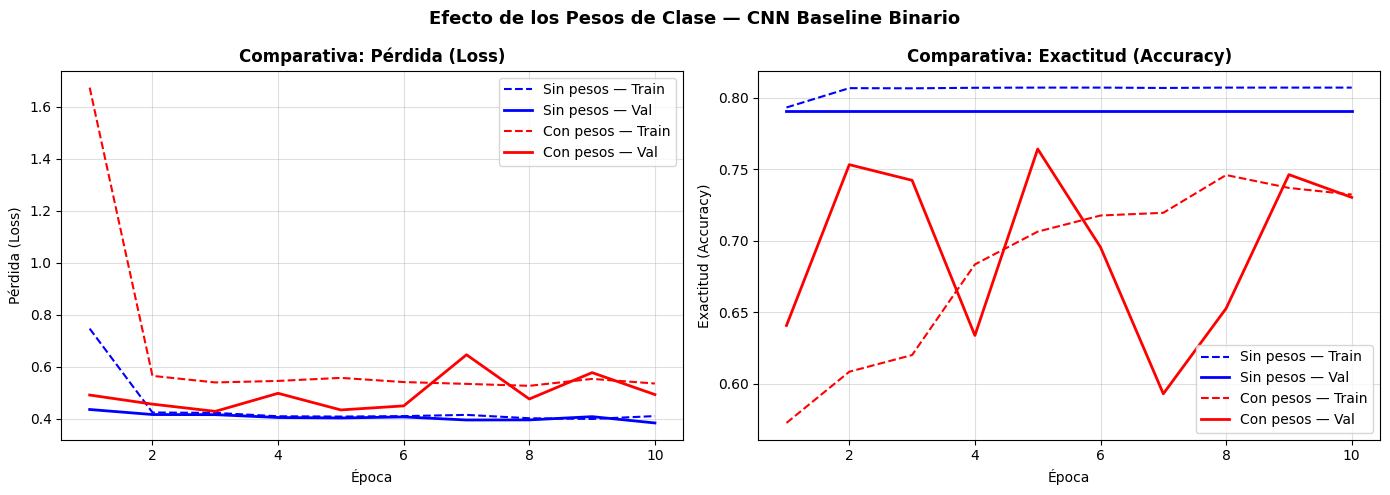

In [ ]:
# ============================================================
# CELDA 8: CURVAS DE APRENDIZAJE COMPARATIVAS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, EPOCHS + 1)

for ax, metrica, titulo in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Pérdida (Loss)', 'Exactitud (Accuracy)']
):
    t_key, v_key = metrica
    ax.plot(epocas, hist_sin[t_key], 'b--', label='Sin pesos — Train')
    ax.plot(epocas, hist_sin[v_key], 'b-',  label='Sin pesos — Val', linewidth=2)
    ax.plot(epocas, hist_con[t_key], 'r--', label='Con pesos — Train')
    ax.plot(epocas, hist_con[v_key], 'r-',  label='Con pesos — Val', linewidth=2)
    ax.set_title(f'Comparativa: {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(titulo)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('Efecto de los Pesos de Clase — CNN Baseline Binario',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig_baseline_curvas_comparativas.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# CELDA 9: FUNCIÓN DE EVALUACIÓN COMPLETA (TEST SET)
# ============================================================
def evaluar_completo(modelo, loader, nombre_modelo='Modelo'):
    """
    Evalúa sobre cualquier loader y retorna métricas completas:
    accuracy, balanced_accuracy, f1_macro, auc_roc, y arrays de preds/labels.
    """
    modelo.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out   = modelo(X)
            probs = torch.softmax(out, dim=1)[:, 1]  # prob de clase Maligno
            preds = out.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc      = (all_preds == all_labels).mean()
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    auc_roc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*50}")
    print(f"  EVALUACIÓN: {nombre_modelo}")
    print(f"{'='*50}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  Balanced Accuracy  : {bal_acc:.4f}  ← métrica principal")
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=['Benigno','Maligno'])}")

    return dict(preds=all_preds, labels=all_labels, probs=all_probs,
                acc=acc, bal_acc=bal_acc, f1_macro=f1_macro, auc_roc=auc_roc)


In [ ]:
# ============================================================
# CELDA 10: EVALUACIÓN FINAL EN TEST SET
# ============================================================
print("Evaluando ambos modelos sobre el conjunto de TEST (datos nunca vistos)...")
res_sin = evaluar_completo(modelo_sin_pesos, test_loader, "Baseline SIN pesos")
res_con = evaluar_completo(modelo_con_pesos, test_loader, "Baseline CON pesos")


Evaluando ambos modelos sobre el conjunto de TEST (datos nunca vistos)...

  EVALUACIÓN: Baseline SIN pesos
  Accuracy           : 0.8012
  Balanced Accuracy  : 0.5000  ← métrica principal
  F1-Score Macro     : 0.4448
  AUC-ROC            : 0.8218

              precision    recall  f1-score   support

     Benigno       0.80      1.00      0.89       822
     Maligno       0.00      0.00      0.00       204

    accuracy                           0.80      1026
   macro avg       0.40      0.50      0.44      1026
weighted avg       0.64      0.80      0.71      1026



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  EVALUACIÓN: Baseline CON pesos
  Accuracy           : 0.7398
  Balanced Accuracy  : 0.6441  ← métrica principal
  F1-Score Macro     : 0.6288
  AUC-ROC            : 0.7723

              precision    recall  f1-score   support

     Benigno       0.86      0.80      0.83       822
     Maligno       0.38      0.49      0.43       204

    accuracy                           0.74      1026
   macro avg       0.62      0.64      0.63      1026
weighted avg       0.77      0.74      0.75      1026



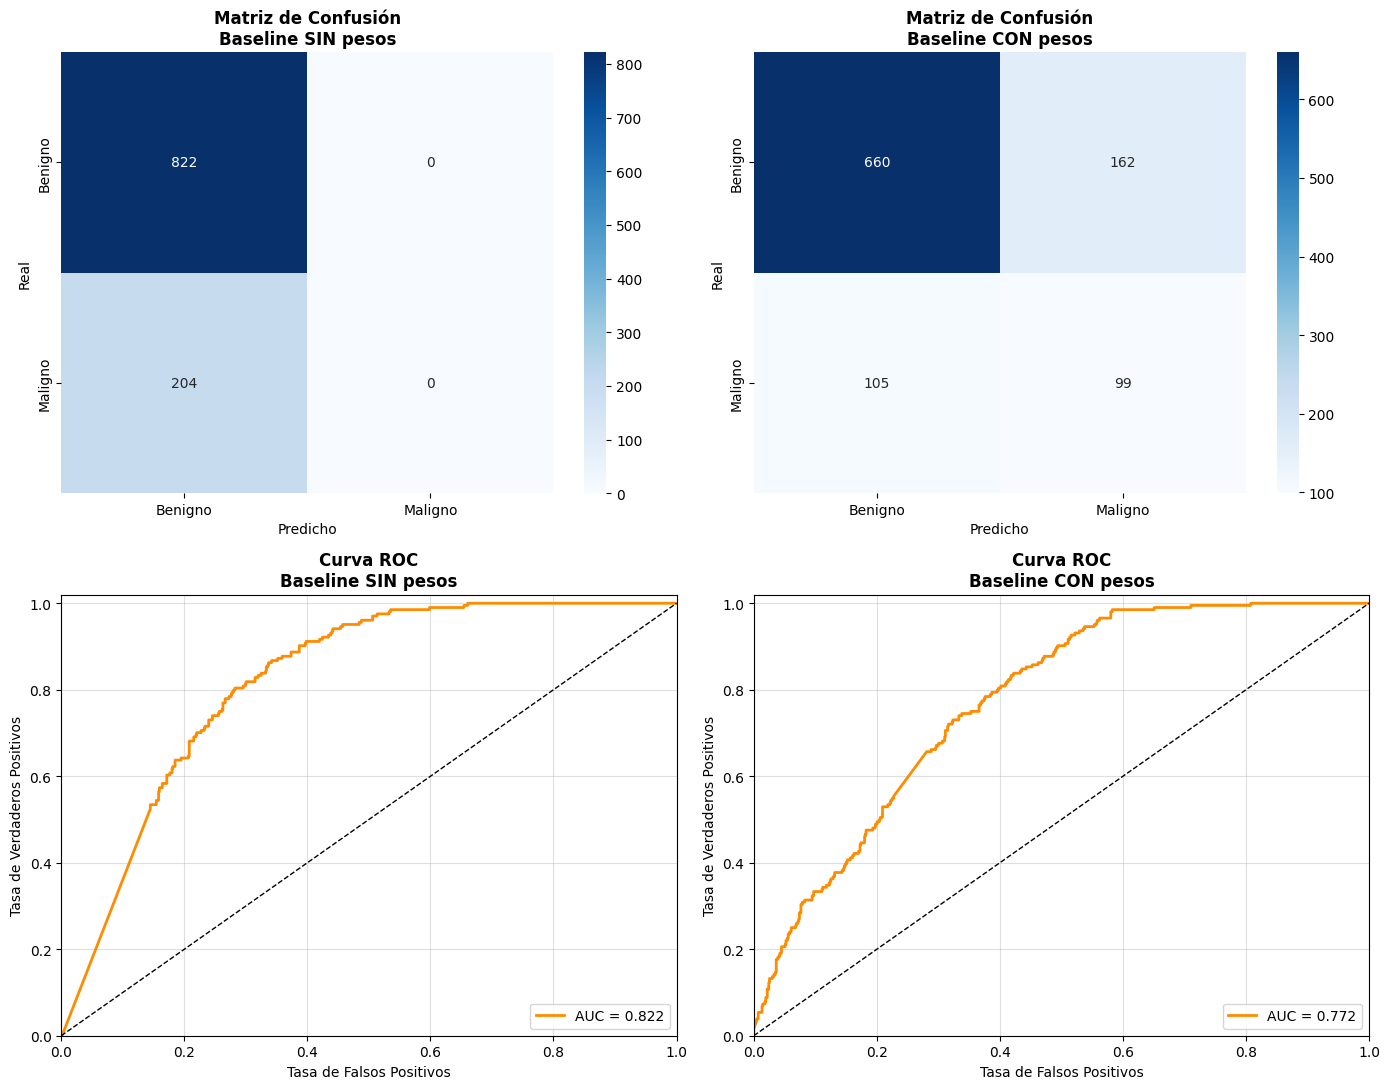


--- TABLA COMPARATIVA FINAL ---
     Métrica  Sin pesos  Con pesos  Δ (Con - Sin)
    Accuracy     0.8012     0.7398        -0.0614
Balanced Acc     0.5000     0.6441         0.1441
    F1 Macro     0.4448     0.6288         0.1840
     AUC-ROC     0.8218     0.7723        -0.0495

✅ Notebook 02 completado.


In [ ]:
# ============================================================
# CELDA 11: MATRICES DE CONFUSIÓN Y CURVAS ROC COMPARATIVAS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
nombres   = ['Baseline SIN pesos', 'Baseline CON pesos']
resultados = [res_sin, res_con]

for col, (res, nombre) in enumerate(zip(resultados, nombres)):
    # Matriz de confusión
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, col],
                xticklabels=['Benigno','Maligno'],
                yticklabels=['Benigno','Maligno'])
    axes[0, col].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    axes[0, col].set_ylabel('Real')
    axes[0, col].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    auc_val = auc(fpr, tpr)
    axes[1, col].plot(fpr, tpr, color='darkorange', lw=2,
                      label=f'AUC = {auc_val:.3f}')
    axes[1, col].plot([0,1],[0,1],'k--', lw=1)
    axes[1, col].set_xlim([0,1]); axes[1, col].set_ylim([0,1.02])
    axes[1, col].set_title(f'Curva ROC\n{nombre}', fontweight='bold')
    axes[1, col].set_xlabel('Tasa de Falsos Positivos')
    axes[1, col].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1, col].legend(loc='lower right')
    axes[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/fig_baseline_evaluacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen comparativa ──
print("\n--- TABLA COMPARATIVA FINAL ---")
metricas = ['acc','bal_acc','f1_macro','auc_roc']
etiquetas = ['Accuracy','Balanced Acc','F1 Macro','AUC-ROC']
df_comp = pd.DataFrame({
    'Métrica'       : etiquetas,
    'Sin pesos'     : [round(res_sin[m], 4) for m in metricas],
    'Con pesos'     : [round(res_con[m], 4) for m in metricas],
    'Δ (Con - Sin)' : [round(res_con[m] - res_sin[m], 4) for m in metricas]
})
print(df_comp.to_string(index=False))
print("\n✅ Notebook 02 completado.")
